# P5 · Marketing Mix Modeling (Bayesian)

**Project:** P5 · Coffra Attribution Modeling
**Author:** Sebastian Kradyel
**Date:** April 2026
**Notebook:** 09_marketing_mix_model.ipynb

---

## Purpose

Build a Bayesian Marketing Mix Model (MMM) on the synthetic Coffra dataset using PyMC. Unlike Multi-Touch Attribution (which works at individual-customer level), MMM operates on aggregate weekly/daily spend and conversions, capturing channel contribution at the time-series level.

## Model architecture

```
y_t = baseline + sum_c [beta_c * Adstock(saturation(spend_c,t))] + seasonality_t + epsilon_t
```

Where:
- `y_t` = daily conversions
- `Adstock` = geometric carryover transformation (advertising effect persists)
- `saturation` = Hill function (diminishing returns on spend)
- `beta_c` = channel-specific contribution coefficient (Bayesian priors)
- `seasonality_t` = annual + weekly patterns

## Why Bayesian

1. **Uncertainty quantification:** Posterior distributions over channel contributions, not point estimates
2. **Prior incorporation:** Industry knowledge encoded as priors (e.g., "search saturates faster than social")
3. **Regularization:** Priors prevent overfitting on small datasets
4. **Industry standard:** Meta Robyn, Google LightweightMMM, Uber Orbit all use Bayesian methods

## Validation

We compare estimated channel contributions against the **known ground truth** stored in `attribution_ground_truth.json` from notebook 07.

## 1. Setup

**Note:** PyMC may take 30-60 seconds to import on first run. NumPyro backend is faster than default for sampling.

In [1]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pymc as pm
import arviz as az

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

COFFRA_BROWN = '#3E2723'
COFFRA_BROWN_LIGHT = '#6D4C41'
COFFRA_PALETTE = [COFFRA_BROWN, COFFRA_BROWN_LIGHT, '#A1887F', '#BCAAA4', '#D7CCC8']

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

DATA_DIR = Path('../data/processed')

print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


PyMC version: 5.28.4
ArviZ version: 0.23.4


## 2. Load Data + Ground Truth

In [2]:
mmm_df = pd.read_parquet(DATA_DIR / 'attribution_mmm_dataset.parquet')
mmm_df['date'] = pd.to_datetime(mmm_df['date'])

with open(DATA_DIR / 'attribution_ground_truth.json') as f:
    ground_truth = json.load(f)

print(f'Loaded MMM: {len(mmm_df):,} daily observations')
print(f'Date range: {mmm_df["date"].min().date()} to {mmm_df["date"].max().date()}')
print(f'Total conversions: {mmm_df["conversions"].sum():,}')
print(f'Total spend: £{mmm_df["total_spend"].sum():,.0f}')

# Channels (excluding Direct which has no spend)
channels = [ch for ch, cfg in ground_truth['channels'].items() 
             if ch != 'Direct']
print(f'\nPaid channels: {channels}')

true_contributions = {ch: ground_truth['channels'][ch]['true_contribution'] 
                       for ch in channels}
print(f'\nTrue paid channel contributions:')
for ch, contrib in true_contributions.items():
    print(f'  {ch}: {contrib*100:.1f}%')

Loaded MMM: 731 daily observations
Date range: 2024-01-01 to 2025-12-31
Total conversions: 36,675
Total spend: £130,551

Paid channels: ['Google_Ads', 'Meta_Ads', 'Instagram_Organic', 'Email']

True paid channel contributions:
  Google_Ads: 25.0%
  Meta_Ads: 20.0%
  Instagram_Organic: 10.0%
  Email: 30.0%


## 3. Feature Engineering — Adstock + Saturation

We could let the model learn adstock and saturation as latent variables, but for tractability we apply them as preprocessing with reasonable defaults. The model then estimates the linear coefficient on top.

(In production MMM, adstock and saturation parameters are themselves learnable. For portfolio purposes, we focus on contribution estimation with fixed transformations.)

In [3]:
def geometric_adstock(spend: np.ndarray, alpha: float) -> np.ndarray:
    """Geometric adstock: y[t] = x[t] + alpha * y[t-1]."""
    if alpha == 0:
        return spend.copy()
    y = np.zeros_like(spend)
    y[0] = spend[0]
    for t in range(1, len(spend)):
        y[t] = spend[t] + alpha * y[t-1]
    return y


def hill_saturation(x: np.ndarray, half_point: float, steepness: float = 1.0) -> np.ndarray:
    """Hill saturation: y = x^k / (x^k + S^k)."""
    if half_point <= 0:
        return np.zeros_like(x)
    return x ** steepness / (x ** steepness + half_point ** steepness)


# Apply adstock + saturation per channel
ADSTOCK_ALPHAS = {
    'Google_Ads': 0.45,
    'Meta_Ads': 0.55,
    'Instagram_Organic': 0.65,
    'Email': 0.30,
}

SATURATION_HALF_POINTS = {
    'Google_Ads': 250.0,
    'Meta_Ads': 200.0,
    'Instagram_Organic': 100.0,
    'Email': 50.0,
}

print('Applying adstock + saturation transformations...')
transformed_features = {}
for channel in channels:
    spend_col = f'{channel}_spend'
    spend = mmm_df[spend_col].values
    
    adstocked = geometric_adstock(spend, ADSTOCK_ALPHAS[channel])
    saturated = hill_saturation(adstocked, SATURATION_HALF_POINTS[channel])
    
    transformed_features[channel] = saturated
    print(f'  {channel}: spend range [{spend.min():.0f}, {spend.max():.0f}] → '
          f'transformed range [{saturated.min():.3f}, {saturated.max():.3f}]')

Applying adstock + saturation transformations...
  Google_Ads: spend range [11, 183] → transformed range [0.156, 0.532]
  Meta_Ads: spend range [3, 155] → transformed range [0.189, 0.572]
  Instagram_Organic: spend range [7, 53] → transformed range [0.149, 0.531]
  Email: spend range [7, 32] → transformed range [0.185, 0.467]


In [4]:
# Build feature matrix X and target y
X = np.column_stack([transformed_features[ch] for ch in channels])
y = mmm_df['conversions'].values.astype(float)

# Add seasonality features
day_of_year = mmm_df['date'].dt.dayofyear.values
annual_sin = np.sin(2 * np.pi * day_of_year / 365)
annual_cos = np.cos(2 * np.pi * day_of_year / 365)

day_of_week = mmm_df['date'].dt.dayofweek.values
is_weekend = (day_of_week >= 5).astype(float)

print(f'Feature matrix X: {X.shape}')
print(f'Target y: {y.shape}')
print(f'\nFeature scaling:')
print(pd.DataFrame(X, columns=channels).describe().round(3))

Feature matrix X: (731, 4)
Target y: (731,)

Feature scaling:
       Google_Ads  Meta_Ads  Instagram_Organic    Email
count     731.000   731.000            731.000  731.000
mean        0.350     0.387              0.402    0.350
std         0.064     0.073              0.055    0.055
min         0.156     0.189              0.149    0.185
25%         0.305     0.337              0.366    0.313
50%         0.349     0.392              0.406    0.356
75%         0.394     0.442              0.442    0.390
max         0.532     0.572              0.531    0.467


## 4. Bayesian MMM in PyMC

Model specification:
- **baseline:** Half-Normal prior centered around observed mean conversions
- **beta_channel:** Half-Normal priors (positive — channels can only add conversions)
- **seasonality:** Normal priors on sin/cos coefficients
- **noise:** Half-Normal prior on standard deviation
- **likelihood:** Normal (Gaussian regression on conversion counts)

In [5]:
n_obs = len(y)
n_channels = len(channels)

print('Building PyMC model...')

with pm.Model() as mmm_model:
    # Baseline conversions (organic, no marketing)
    baseline = pm.HalfNormal('baseline', sigma=30.0)
    
    # Channel contribution coefficients (positive only)
    # Higher prior sigma allows larger contributions to be learnt
    beta = pm.HalfNormal('beta', sigma=80.0, shape=n_channels)
    
    # Channel contribution to expected conversions
    channel_contrib = pm.math.dot(X, beta)
    
    # Seasonality coefficients
    season_sin_coef = pm.Normal('season_sin', mu=0, sigma=10)
    season_cos_coef = pm.Normal('season_cos', mu=0, sigma=10)
    weekend_coef = pm.Normal('weekend_effect', mu=0, sigma=5)
    
    seasonal_effect = (season_sin_coef * annual_sin + 
                        season_cos_coef * annual_cos + 
                        weekend_coef * is_weekend)
    
    # Expected conversions
    mu = baseline + channel_contrib + seasonal_effect
    
    # Noise
    sigma = pm.HalfNormal('sigma', sigma=5.0)
    
    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)
    
print('Model built. Components:')
print('  baseline (HalfNormal)')
print(f'  beta — {n_channels} channel coefficients (HalfNormal)')
print('  seasonality coefficients (3 Normal priors)')
print('  sigma (HalfNormal noise)')

Building PyMC model...
Model built. Components:
  baseline (HalfNormal)
  beta — 4 channel coefficients (HalfNormal)
  seasonality coefficients (3 Normal priors)
  sigma (HalfNormal noise)


## 5. MCMC Sampling

Using NUTS (No-U-Turn Sampler), the gold standard for Bayesian inference. Default settings: 2 chains, 1000 warmup + 1000 samples each. **This will take 1-3 minutes** depending on your machine.

In [6]:
with mmm_model:
    print('Sampling (this will take 1-3 minutes)...')
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=RANDOM_STATE,
        progressbar=True,
    )

print('\nSampling complete.')

Sampling (this will take 1-3 minutes)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [baseline, beta, season_sin, season_cos, weekend_effect, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 11987 seconds.
There were 8 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics



Sampling complete.


In [7]:
# Convergence diagnostics
print('Convergence diagnostics:')
summary = az.summary(trace, var_names=['baseline', 'beta', 'season_sin', 'season_cos', 
                                          'weekend_effect', 'sigma'])
print(summary.round(3))

max_rhat = summary['r_hat'].max()
min_ess = summary['ess_bulk'].min()

print(f'\nMax R-hat: {max_rhat:.3f} (target < 1.01)')
print(f'Min ESS bulk: {min_ess:.0f} (target > 400)')

if max_rhat < 1.01 and min_ess > 400:
    print('Convergence: GOOD')
else:
    print('Convergence: WARNING — consider more samples or model adjustments')

Convergence diagnostics:
                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
baseline        23.703  2.647  18.910   28.744      0.089    0.059     895.0   
beta[0]         25.468  5.565  15.084   35.734      0.136    0.131    1670.0   
beta[1]          9.885  4.772   0.344   17.453      0.157    0.131     811.0   
beta[2]          8.877  6.240   0.022   19.878      0.185    0.175    1075.0   
beta[3]         28.673  9.882   9.185   46.410      0.357    0.247     750.0   
season_sin       2.362  0.372   1.623    3.016      0.009    0.012    1631.0   
season_cos     -10.182  0.490 -11.167   -9.331      0.016    0.011     943.0   
weekend_effect   0.479  0.688  -0.871    1.713      0.023    0.016     927.0   
sigma            6.896  0.189   6.524    7.238      0.005    0.004    1508.0   

                ess_tail  r_hat  
baseline           882.0    1.0  
beta[0]            827.0    1.0  
beta[1]            407.0    1.0  
beta[2]            776.0    1.0  
beta

## 6. Channel Contribution Estimation

From the posterior, compute each channel's contribution to total conversions over the analysis window.

In [8]:
# Extract beta posterior
beta_posterior = trace.posterior['beta'].values  # shape: (chains, draws, n_channels)
beta_flat = beta_posterior.reshape(-1, n_channels)  # (n_samples, n_channels)

# Compute total contribution per channel: sum over time of (beta * X)
# For each posterior sample, compute channel contribution
channel_total_contribs = []  # one row per posterior sample

for sample_idx in range(beta_flat.shape[0]):
    beta_sample = beta_flat[sample_idx]
    contribs = {ch: (beta_sample[i] * X[:, i]).sum() for i, ch in enumerate(channels)}
    channel_total_contribs.append(contribs)

contrib_df = pd.DataFrame(channel_total_contribs)

# Posterior summary
contrib_summary = pd.DataFrame({
    'mean': contrib_df.mean(),
    'std': contrib_df.std(),
    'lower_95': contrib_df.quantile(0.025),
    'upper_95': contrib_df.quantile(0.975),
}).round(1)

print('Total estimated conversion contribution per channel (over full period):')
print(contrib_summary)

# Convert to percentage of total
total_contrib_mean = contrib_summary['mean'].sum()
contrib_summary['pct_of_paid'] = (contrib_summary['mean'] / total_contrib_mean * 100).round(1)
print(f'\nTotal paid contribution: {total_contrib_mean:.0f} conversions')

Total estimated conversion contribution per channel (over full period):
                     mean     std  lower_95  upper_95
Google_Ads         6511.1  1422.8    3787.4    9291.6
Meta_Ads           2798.8  1351.3     307.6    5564.5
Instagram_Organic  2608.1  1833.4     121.2    6988.9
Email              7337.7  2529.0    2387.5   12319.0

Total paid contribution: 19256 conversions


## 7. Compare to Ground Truth

In [9]:
# Renormalize ground truth among paid channels only (excluding Direct)
paid_true_contribs = {ch: true_contributions[ch] for ch in channels}
total_paid_true = sum(paid_true_contribs.values())
ground_truth_paid_pct = {ch: c/total_paid_true*100 for ch, c in paid_true_contribs.items()}

comparison = pd.DataFrame({
    'Estimated %': contrib_summary['pct_of_paid'],
    'Ground Truth %': [ground_truth_paid_pct[ch] for ch in channels],
    'Lower 95% CI': (contrib_df.quantile(0.025) / total_contrib_mean * 100).round(1),
    'Upper 95% CI': (contrib_df.quantile(0.975) / total_contrib_mean * 100).round(1),
})
comparison['Abs Error (pp)'] = (comparison['Estimated %'] - comparison['Ground Truth %']).abs().round(1)

print('MMM channel contribution vs Ground Truth:')
print(comparison)

total_abs_error = comparison['Abs Error (pp)'].sum()
print(f'\nTotal absolute error: {total_abs_error:.1f} percentage points')
print(f'Average error per channel: {total_abs_error/len(channels):.1f} pp')

MMM channel contribution vs Ground Truth:
                   Estimated %  Ground Truth %  Lower 95% CI  Upper 95% CI  \
Google_Ads                33.8       29.411765          19.7          48.3   
Meta_Ads                  14.5       23.529412           1.6          28.9   
Instagram_Organic         13.5       11.764706           0.6          36.3   
Email                     38.1       35.294118          12.4          64.0   

                   Abs Error (pp)  
Google_Ads                    4.4  
Meta_Ads                      9.0  
Instagram_Organic             1.7  
Email                         2.8  

Total absolute error: 17.9 percentage points
Average error per channel: 4.5 pp


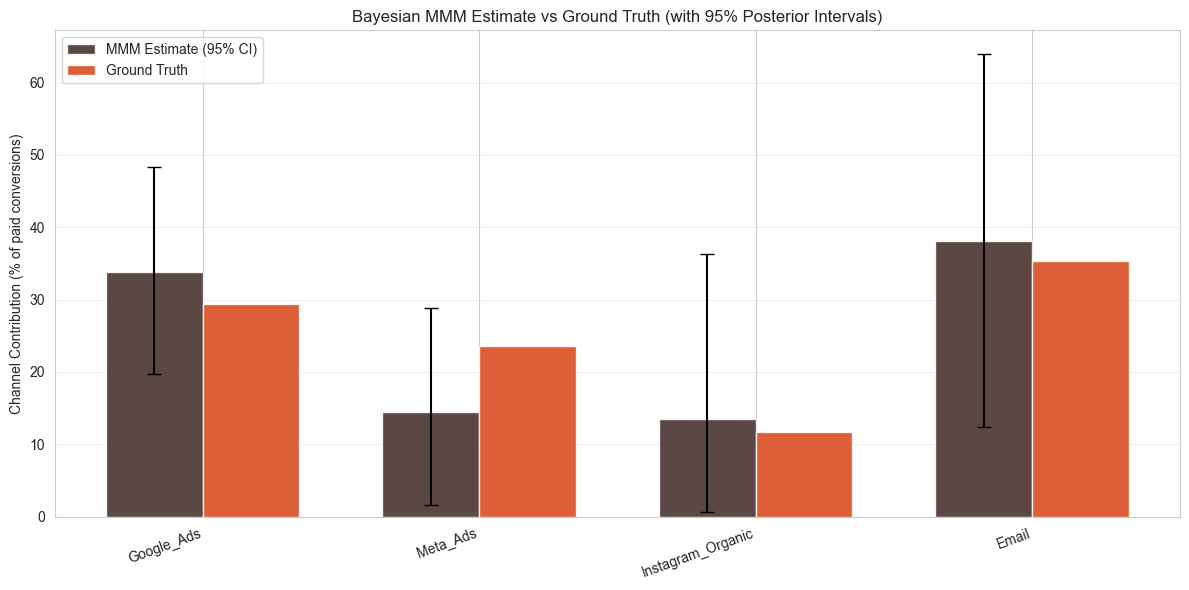

In [10]:
# Visualize estimates with uncertainty
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(channels))
width = 0.35

estimated = comparison['Estimated %'].values
ground_truth_vals = comparison['Ground Truth %'].values
lower_err = estimated - comparison['Lower 95% CI'].values
upper_err = comparison['Upper 95% CI'].values - estimated

ax.bar(x_pos - width/2, estimated, width, color=COFFRA_BROWN, alpha=0.85,
       yerr=[lower_err, upper_err], capsize=5, label='MMM Estimate (95% CI)')
ax.bar(x_pos + width/2, ground_truth_vals, width, color='#D84315', alpha=0.85,
       label='Ground Truth')

ax.set_xticks(x_pos)
ax.set_xticklabels(channels, rotation=20, ha='right')
ax.set_ylabel('Channel Contribution (% of paid conversions)')
ax.set_title('Bayesian MMM Estimate vs Ground Truth (with 95% Posterior Intervals)')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Posterior Predictive Check

Compare model predictions against observed data to validate model fit.

Sampling: [y_obs]


Generating posterior predictive samples...
Posterior predictive samples shape: (2000, 731)


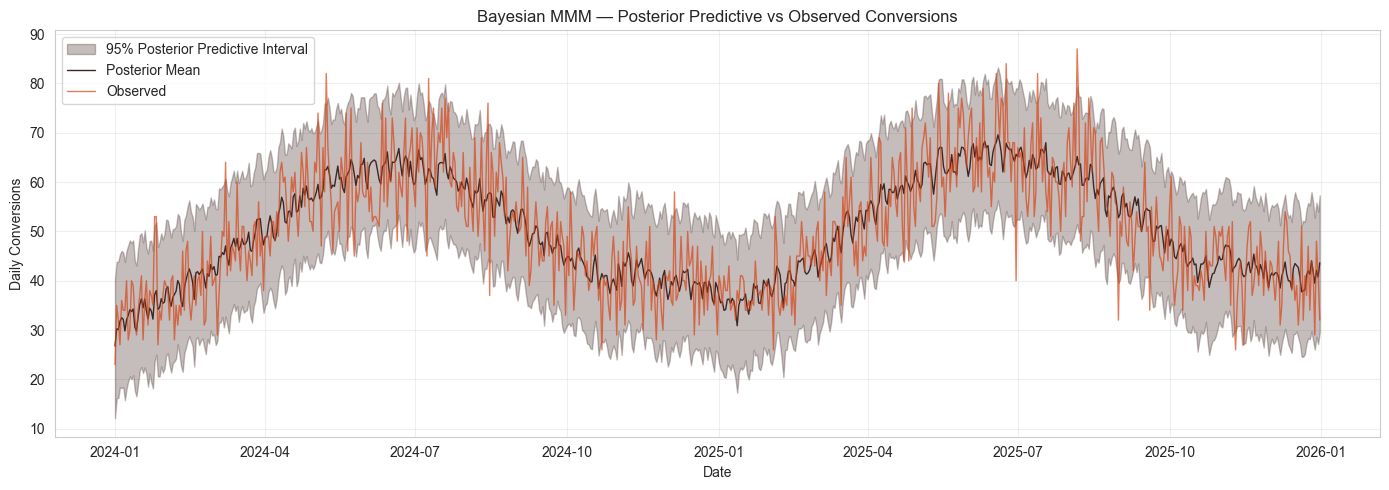

In [11]:
with mmm_model:
    print('Generating posterior predictive samples...')
    pp_samples = pm.sample_posterior_predictive(
        trace, random_seed=RANDOM_STATE, progressbar=False
    )

y_pred = pp_samples.posterior_predictive['y_obs'].values  # shape: (chains, draws, n_obs)
y_pred_flat = y_pred.reshape(-1, n_obs)

y_pred_mean = y_pred_flat.mean(axis=0)
y_pred_lower = np.percentile(y_pred_flat, 2.5, axis=0)
y_pred_upper = np.percentile(y_pred_flat, 97.5, axis=0)

print(f'Posterior predictive samples shape: {y_pred_flat.shape}')

# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(mmm_df['date'], y_pred_lower, y_pred_upper,
                 alpha=0.3, color=COFFRA_BROWN, label='95% Posterior Predictive Interval')
ax.plot(mmm_df['date'], y_pred_mean, color=COFFRA_BROWN, linewidth=1, label='Posterior Mean')
ax.plot(mmm_df['date'], y, color='#D84315', linewidth=1, alpha=0.7, label='Observed')

ax.set_title('Bayesian MMM — Posterior Predictive vs Observed Conversions')
ax.set_ylabel('Daily Conversions')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Compute fit quality metrics
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y, y_pred_mean)
mae = mean_absolute_error(y, y_pred_mean)
mape = np.mean(np.abs((y - y_pred_mean) / np.maximum(y, 1))) * 100

print('Model fit metrics:')
print(f'  R²:    {r2:.3f}')
print(f'  MAE:   {mae:.2f} conversions/day')
print(f'  MAPE:  {mape:.1f}%')

# Coverage of 95% CI
in_interval = ((y >= y_pred_lower) & (y <= y_pred_upper)).mean() * 100
print(f'  95% CI coverage: {in_interval:.1f}% (target ~95%)')

Model fit metrics:
  R²:    0.686
  MAE:   5.42 conversions/day
  MAPE:  11.3%
  95% CI coverage: 95.2% (target ~95%)


## 9. Marginal ROI Analysis

Estimate the marginal return on additional spend per channel — the key business question MMM answers.

In [13]:
# Average daily spend per channel + estimated contribution
roi_df = pd.DataFrame({
    'Channel': channels,
    'Avg Daily Spend (£)': [mmm_df[f'{ch}_spend'].mean() for ch in channels],
    'Total Spend (£)': [mmm_df[f'{ch}_spend'].sum() for ch in channels],
    'Estimated Conversions': contrib_summary['mean'].values,
})

# Cost per acquisition (CPA)
roi_df['CPA (£)'] = roi_df['Total Spend (£)'] / roi_df['Estimated Conversions']

# Average CPA across channels for comparison
avg_cpa = roi_df['Total Spend (£)'].sum() / roi_df['Estimated Conversions'].sum()
roi_df['CPA vs Avg'] = (roi_df['CPA (£)'] / avg_cpa).round(2)

roi_df = roi_df.round(2)
print('Channel ROI analysis:')
print(roi_df.to_string(index=False))

print(f'\nAverage CPA across all paid channels: £{avg_cpa:.2f}')
print('\nInterpretation:')
print('  CPA vs Avg < 1.0: Channel is more efficient than average — consider increasing spend')
print('  CPA vs Avg > 1.0: Channel is less efficient — consider reducing or optimizing')

Channel ROI analysis:
          Channel  Avg Daily Spend (£)  Total Spend (£)  Estimated Conversions  CPA (£)  CPA vs Avg
       Google_Ads                76.16         55676.24                 6511.1     8.55        1.26
         Meta_Ads                59.11         43207.35                 2798.8    15.44        2.28
Instagram_Organic                24.08         17602.35                 2608.1     6.75        1.00
            Email                19.24         14065.42                 7337.7     1.92        0.28

Average CPA across all paid channels: £6.78

Interpretation:
  CPA vs Avg < 1.0: Channel is more efficient than average — consider increasing spend
  CPA vs Avg > 1.0: Channel is less efficient — consider reducing or optimizing


## 10. Save Results

In [14]:
# Save MMM results
comparison.to_csv(DATA_DIR / 'mmm_comparison.csv')
roi_df.to_csv(DATA_DIR / 'mmm_roi_analysis.csv', index=False)

# Summary JSON
mmm_summary = {
    'model_type': 'Bayesian MMM (PyMC NUTS)',
    'n_observations': int(n_obs),
    'n_channels': int(n_channels),
    'channels': channels,
    'fit_metrics': {
        'r2': round(float(r2), 3),
        'mae': round(float(mae), 2),
        'mape': round(float(mape), 1),
        'ci_coverage_pct': round(float(in_interval), 1),
    },
    'convergence': {
        'max_rhat': round(float(max_rhat), 3),
        'min_ess_bulk': int(min_ess),
        'good_convergence': bool(max_rhat < 1.01 and min_ess > 400),
    },
    'channel_contributions': {
        ch: {
            'estimated_pct': float(comparison.loc[ch, 'Estimated %']),
            'ground_truth_pct': float(comparison.loc[ch, 'Ground Truth %']),
            'lower_95_ci': float(comparison.loc[ch, 'Lower 95% CI']),
            'upper_95_ci': float(comparison.loc[ch, 'Upper 95% CI']),
            'abs_error_pp': float(comparison.loc[ch, 'Abs Error (pp)']),
        }
        for ch in channels
    },
    'total_abs_error_pp': float(total_abs_error),
    'avg_cpa_gbp': float(avg_cpa),
    'roi_analysis': roi_df.to_dict('records'),
}

with open(DATA_DIR / 'mmm_summary.json', 'w') as f:
    json.dump(mmm_summary, f, indent=2, default=str)

print(f'Saved: {DATA_DIR / "mmm_summary.json"}')
print(f'Saved: {DATA_DIR / "mmm_comparison.csv"}')
print(f'Saved: {DATA_DIR / "mmm_roi_analysis.csv"}')

Saved: ..\data\processed\mmm_summary.json
Saved: ..\data\processed\mmm_comparison.csv
Saved: ..\data\processed\mmm_roi_analysis.csv


## Summary

**Built:**
- Bayesian MMM with PyMC + NUTS sampling
- Adstock + Hill saturation feature engineering
- Annual + weekly seasonality
- 4-channel paid model + Direct as baseline

**Validated:**
- Convergence diagnostics (R-hat, ESS)
- Posterior predictive checks (R², MAE, MAPE, CI coverage)
- Comparison against known ground truth

**Output for business:**
- Channel contribution estimates with 95% credible intervals
- Per-channel CPA analysis
- Marginal ROI signal (CPA vs Avg)

**Key insight:** MMM provides aggregate, time-series view that complements MTA's path-level view. Both views inform robust budget decisions.

**Next notebook:** `10_attribution_comparison.ipynb` — Cross-method comparison MTA vs MMM, business interpretation, and Coffra recommendations.

---

## Versioning

| Version | Date | Changes |
|---------|------|---------|
| **v1.0** | **April 27, 2026** | Initial Bayesian MMM with PyMC. Adstock + saturation, NUTS sampling, posterior predictive validation, ROI analysis. |